In [7]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ---------------------------- ----------- 1.0/1.5 MB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

In [10]:
import os
print(os.listdir())

['car.ipynb', 'car_evaluation.csv']


In [27]:
import pandas as pd

columns = [
    'buying',
    'maint',
    'doors',
    'persons',
    'lug_boot',
    'safety',
    'class'
]

df = pd.read_csv(
    'car_evaluation.csv',
    header=None,
    names=columns
)

print(df.head())
print(df.shape)

  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc
(1728, 7)


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [34]:
df.describe(include = 'object')

,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [35]:
print(df.isnull().sum())

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


In [36]:
print("duplicates:", df.duplicated().sum())

duplicates: 0


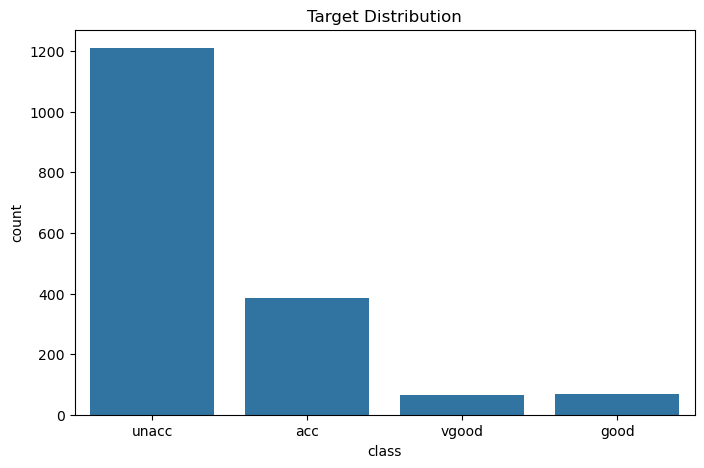

In [28]:
plt.figure(figsize=(8,5))

sns.countplot( x='class',data=df)

plt.title("Target Distribution")
plt.show()

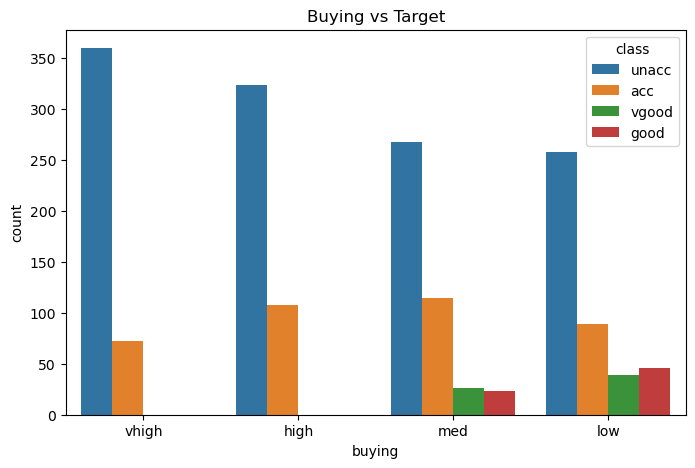

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='buying',
    hue='class',
    data=df
)

plt.title("Buying vs Target")
plt.show()

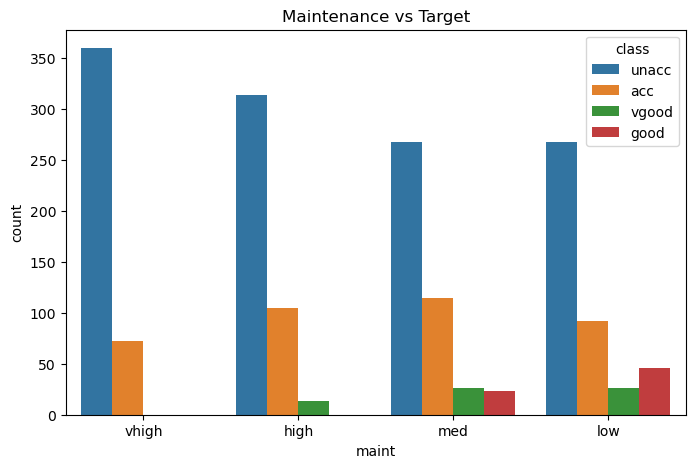

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='maint',
    hue='class',
    data=df
)

plt.title("Maintenance vs Target")
plt.show()

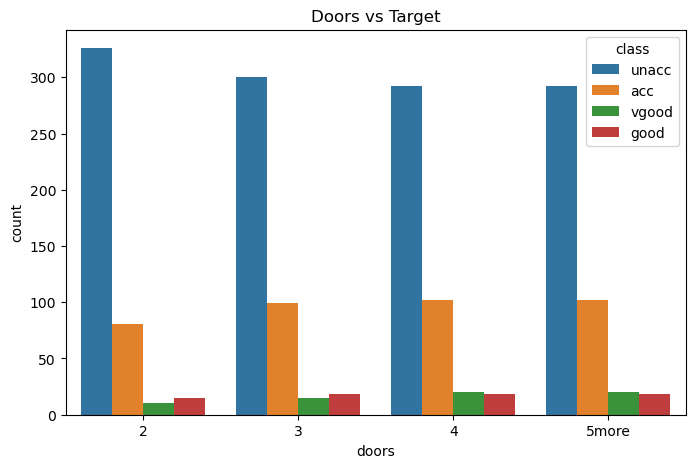

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='doors',
    hue='class',
    data=df
)

plt.title("Doors vs Target")
plt.show()

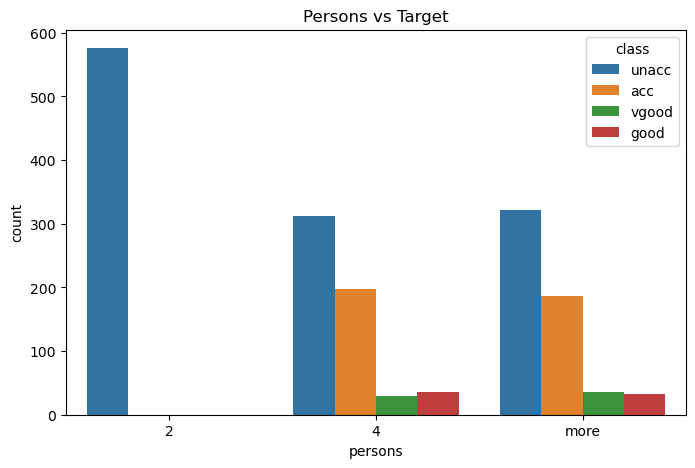

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='persons',
    hue='class',
    data=df
)

plt.title("Persons vs Target")
plt.show()

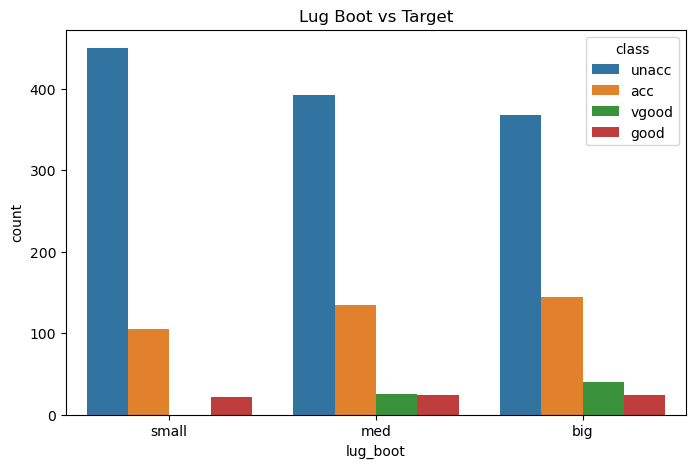

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='lug_boot',
    hue='class',
    data=df
)

plt.title("Lug Boot vs Target")
plt.show()

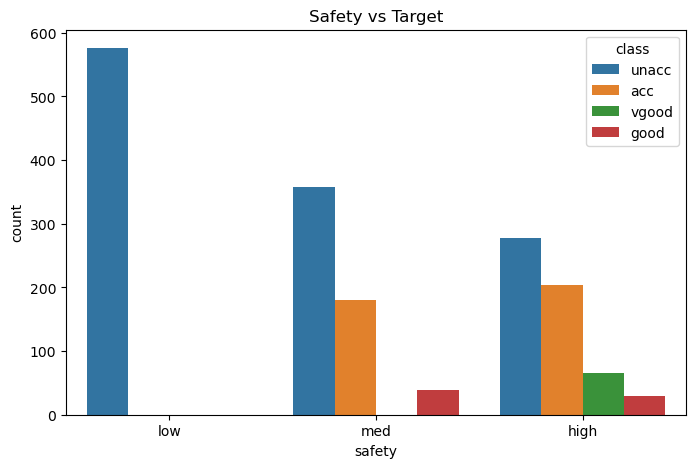

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='safety',
    hue='class',
    data=df
)

plt.title("Safety vs Target")
plt.show()

In [39]:
encoder = LabelEncoder()

for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


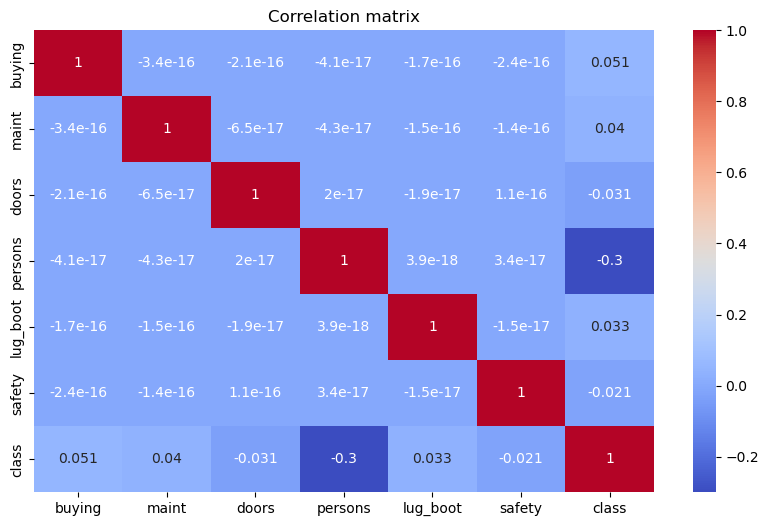

In [40]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

plt.title("Correlation matrix")
plt.show()

In [42]:
X = df.drop('class', axis =1)
y = df['class']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,
random_state = 42, stratify =y)

In [45]:
models = {
    "Decesion Tree": DecisionTreeClassifier(max_depth =12, random_state =42),
    "Random Forest": RandomForestClassifier(n_estimators=500,max_depth=15,random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300,max_depth=8,learning_rate=0.05,random_state=42),
    "CatBoost":CatBoostClassifier(iterations=300,depth=8,verbose=0),
    "LightGBM":LGBMClassifier(n_estimators=300,learning_rate=0.05)
}

In [47]:
results =[]
for name,model in models.items():
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test,pred)
    results.append([name,acc])

    print("\n")
    print("="*50)
    print(name)
    print("Accuracy:", acc)
    print(classification_report(y_test,pred))



Decesion Tree
Accuracy: 0.9884393063583815
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        77
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00       242
           3       1.00      0.85      0.92        13

    accuracy                           0.99       346
   macro avg       0.97      0.96      0.96       346
weighted avg       0.99      0.99      0.99       346



Random Forest
Accuracy: 0.9797687861271677
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        77
           1       0.93      0.93      0.93        14
           2       0.98      1.00      0.99       242
           3       1.00      0.92      0.96        13

    accuracy                           0.98       346
   macro avg       0.97      0.95      0.96       346
weighted avg       0.98      0.98      0.98       346



XGBoost
Accuracy: 0.9942196531791907
 

In [49]:
results_df = pd.DataFrame(results,columns=['Model','Accuracy'])

results_df = results_df.sort_values( by='Accuracy', ascending=False)

print(results_df)

           Model  Accuracy
4       LightGBM  1.000000
3       CatBoost  1.000000
2        XGBoost  0.994220
0  Decesion Tree  0.988439
1  Random Forest  0.979769


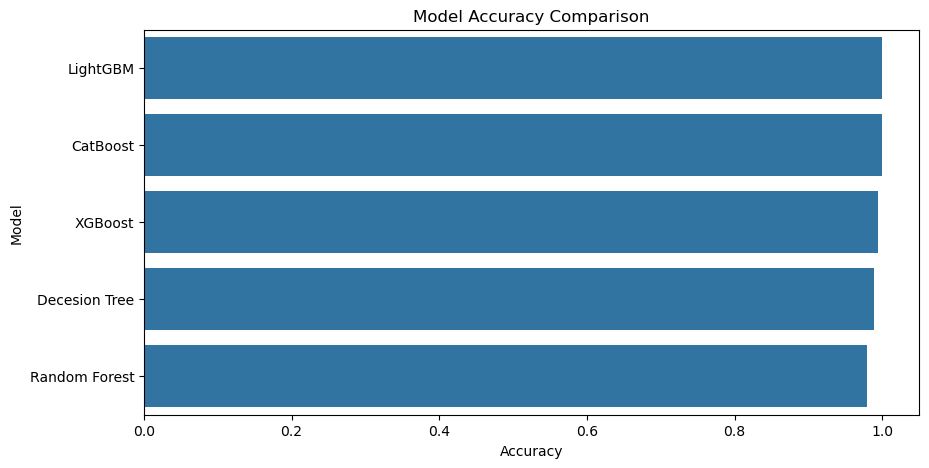

In [54]:
plt.figure(figsize=(10,5))
sns.barplot(x='Accuracy',y='Model',data=results_df)

plt.title("Model Accuracy Comparison")
plt.show()

In [52]:
best_model = CatBoostClassifier(
    iterations=300,
    depth=8,
    verbose=0
)

best_model.fit(
    X_train,
    y_train
)

pred = best_model.predict(
    X_test
)

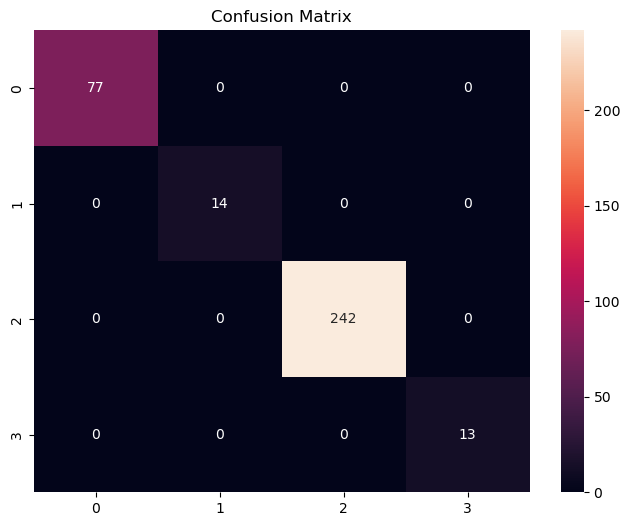

In [53]:
cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [55]:
import joblib

# Train model
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

# Save model
joblib.dump(rf, "car_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
